<a href="https://colab.research.google.com/github/syedahijabzahra/DevelopersHub-AI-ML-Internship/blob/main/Heart_Disease_Prediction/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn kagglehub -q

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


In [3]:
# Option A: Download from Kaggle (requires kaggle.json credentials)
# !kaggle datasets download -d redwankarimsony/heart-disease-data -p ./data --unzip

# Option B: Load directly using URL (Cleveland Heart Disease - UCI)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
col_names = ['age','sex','cp','trestbps','chol','fbs','restecg',
             'thalach','exang','oldpeak','slope','ca','thal','target']

df = pd.read_csv(url, names=col_names, na_values='?')
print(f'Shape: {df.shape}')
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing: 6


In [5]:
# Fill missing values with column median
df.fillna(df.median(numeric_only=True), inplace=True)

# Binarize target: 0 = No disease, 1 = Disease
df['target'] = (df['target'] > 0).astype(int)

print('Target distribution:')
print(df['target'].value_counts())
print(f'\nNo missing values remaining: {df.isnull().sum().sum() == 0} ✅')

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

No missing values remaining: True ✅


In [6]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


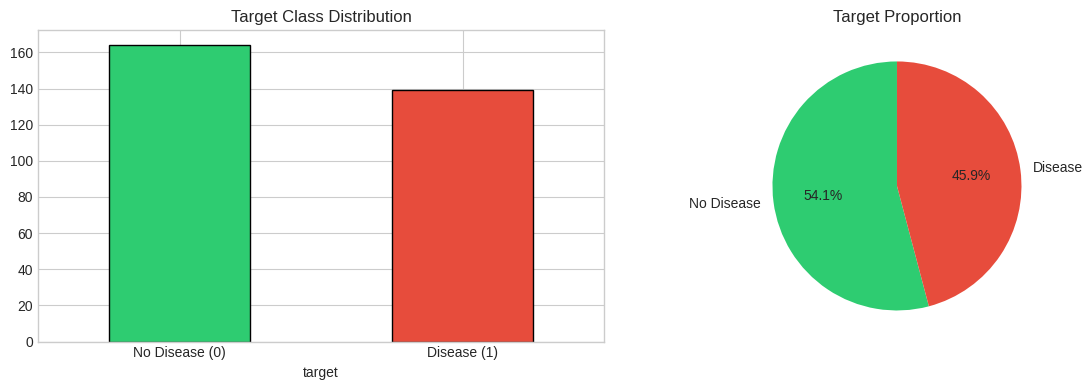

In [7]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Target Class Distribution')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)

df['target'].value_counts().plot(kind='pie', ax=axes[1], labels=['No Disease','Disease'],
                                  colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

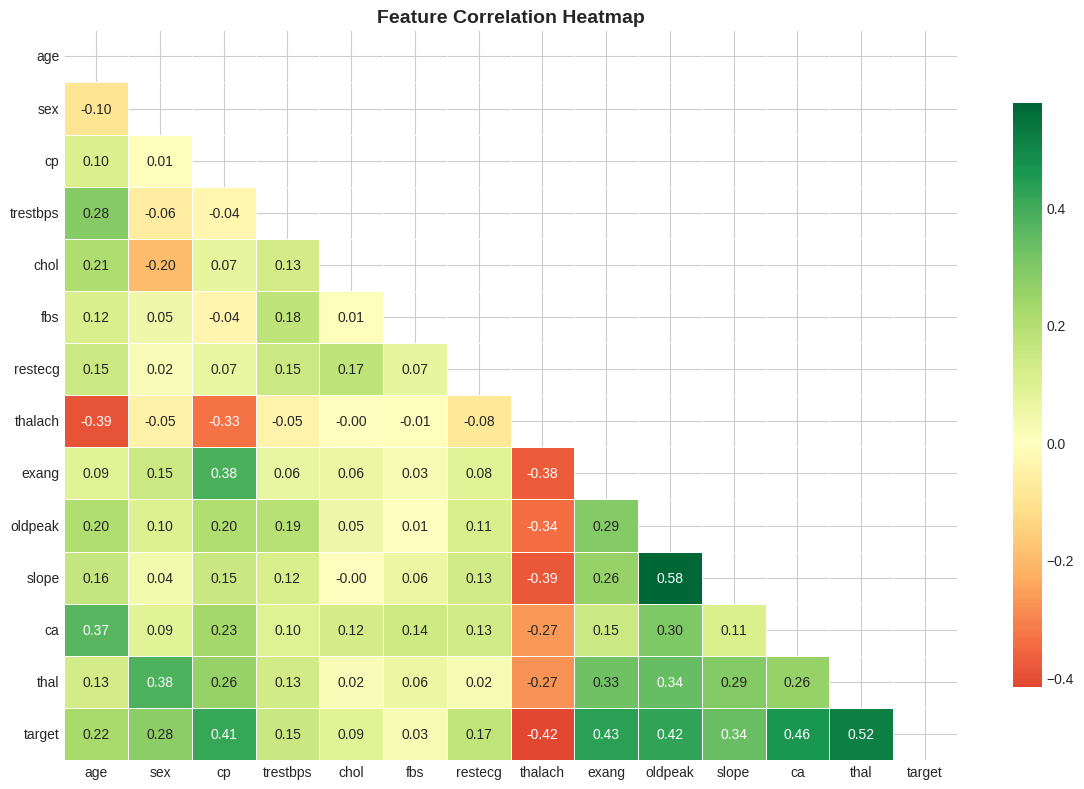

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

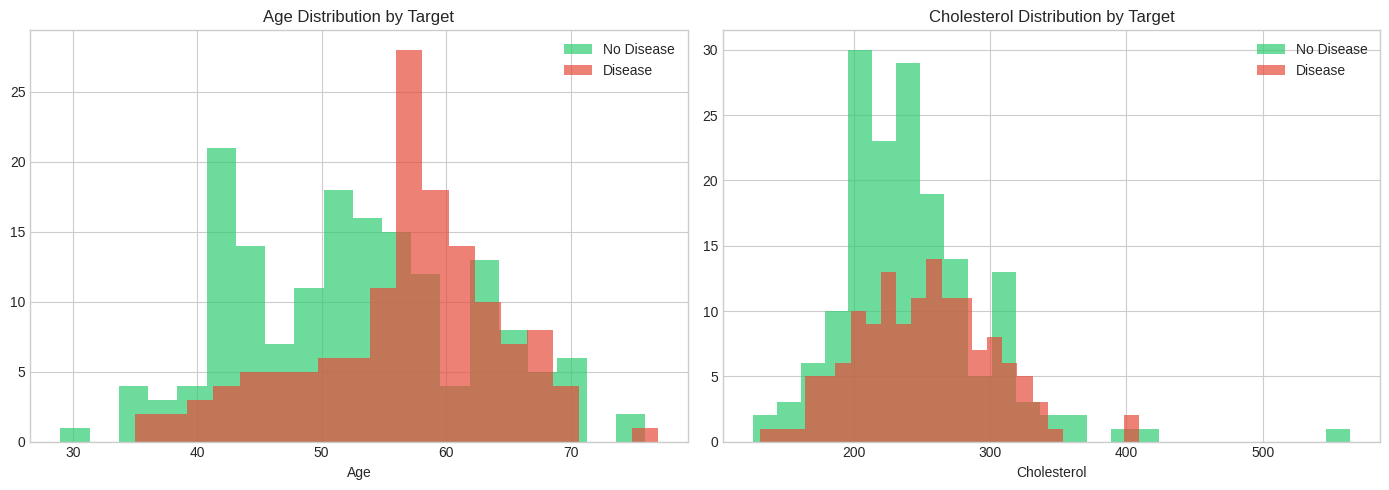

In [9]:
# Age & Cholesterol distributions by target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tgt, color, label in [(0,'#2ecc71','No Disease'), (1,'#e74c3c','Disease')]:
    axes[0].hist(df[df['target']==tgt]['age'], bins=20, alpha=0.7, color=color, label=label)
    axes[1].hist(df[df['target']==tgt]['chol'], bins=25, alpha=0.7, color=color, label=label)

axes[0].set_title('Age Distribution by Target'); axes[0].set_xlabel('Age'); axes[0].legend()
axes[1].set_title('Cholesterol Distribution by Target'); axes[1].set_xlabel('Cholesterol'); axes[1].legend()
plt.tight_layout()
plt.savefig('age_chol_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

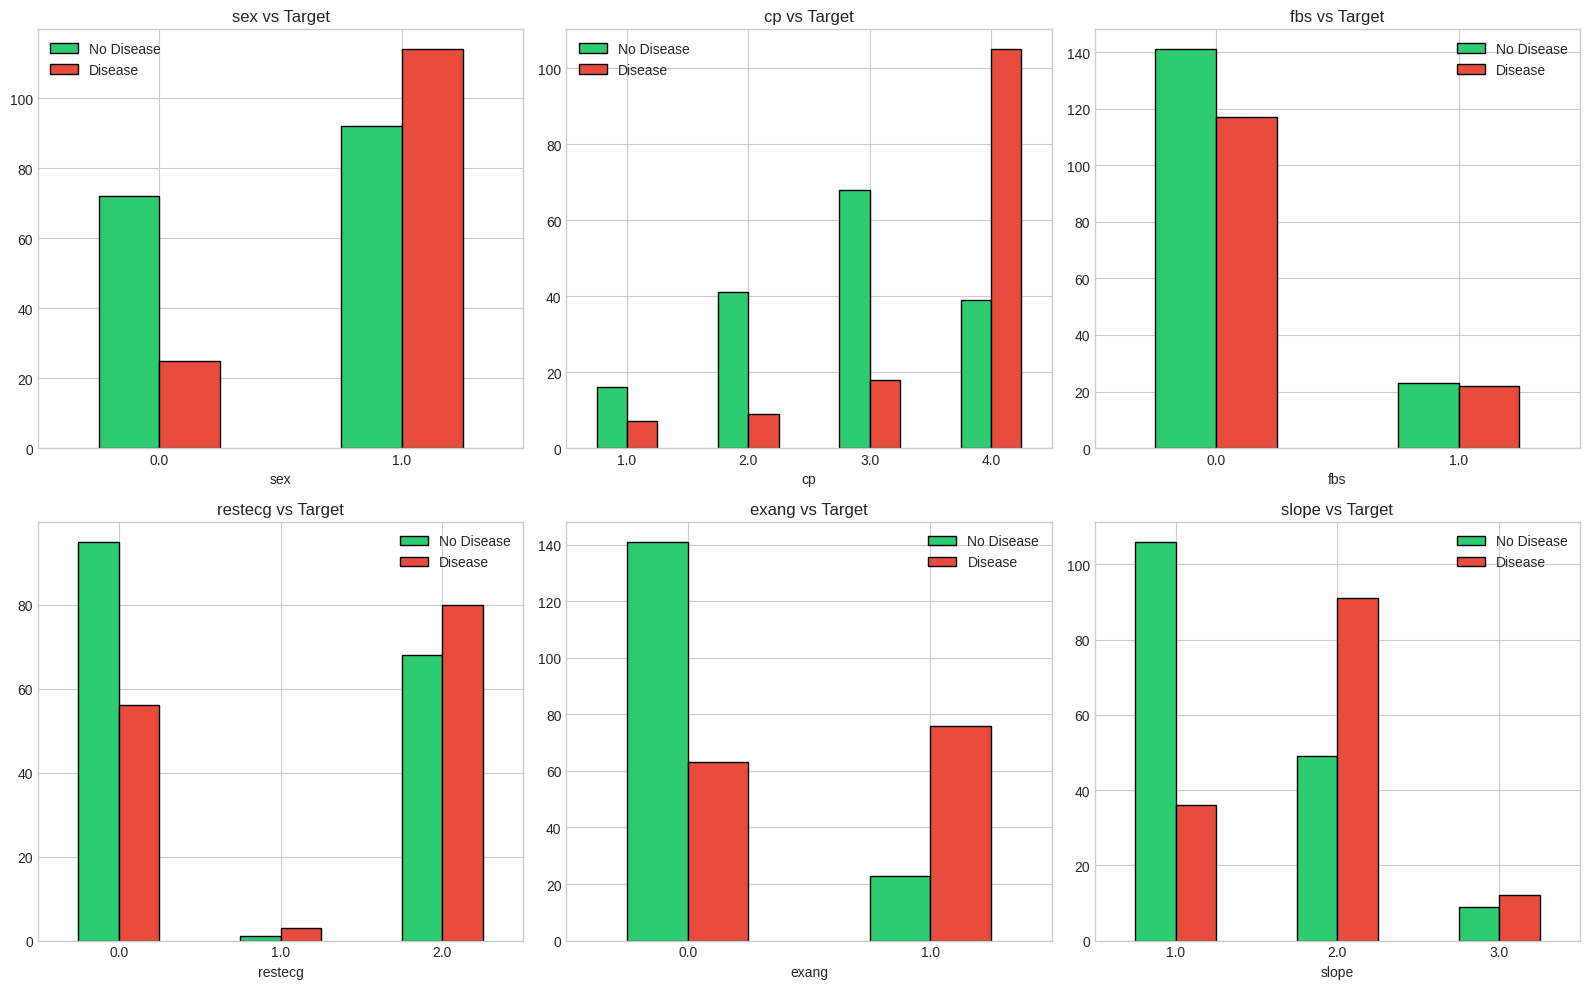

In [10]:
# Categorical features vs target
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71','#e74c3c'], edgecolor='black', rot=0)
    axes[i].set_title(f'{col} vs Target')
    axes[i].legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.savefig('categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 242 | Test size: 61


In [12]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr   = lr.predict(X_test_sc)
y_prob_lr   = lr.predict_proba(X_test_sc)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f'Logistic Regression → Accuracy: {acc_lr:.4f} | ROC-AUC: {auc_lr:.4f}')

Logistic Regression → Accuracy: 0.8689 | ROC-AUC: 0.9513


In [13]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f'Decision Tree       → Accuracy: {acc_dt:.4f} | ROC-AUC: {auc_dt:.4f}')

Decision Tree       → Accuracy: 0.7869 | ROC-AUC: 0.8047


In [14]:
# Classification Reports
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['No Disease','Disease']))
print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['No Disease','Disease']))

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

=== Decision Tree ===
              precision    recall  f1-score   support

  No Disease       0.86      0.73      0.79        33
     Disease       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



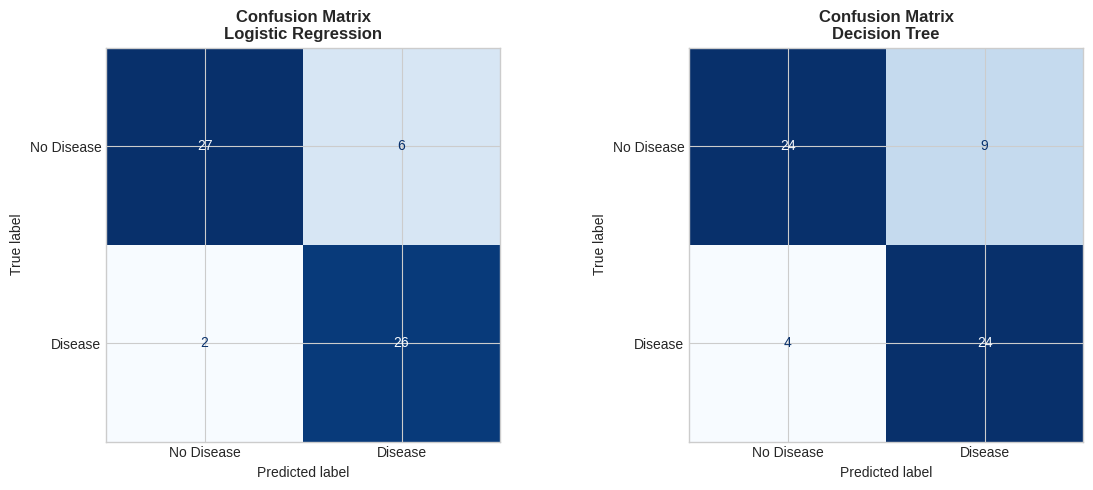

In [15]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

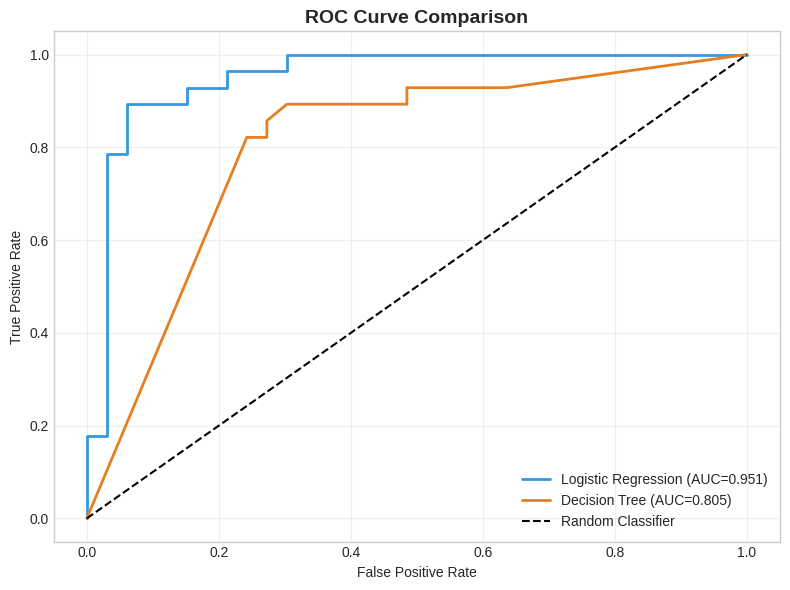

In [16]:
# ROC Curves
plt.figure(figsize=(8, 6))

for y_prob, label, color in [
    (y_prob_lr, f'Logistic Regression (AUC={auc_lr:.3f})', '#3498db'),
    (y_prob_dt, f'Decision Tree (AUC={auc_dt:.3f})', '#e67e22')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=label, color=color, lw=2)

plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

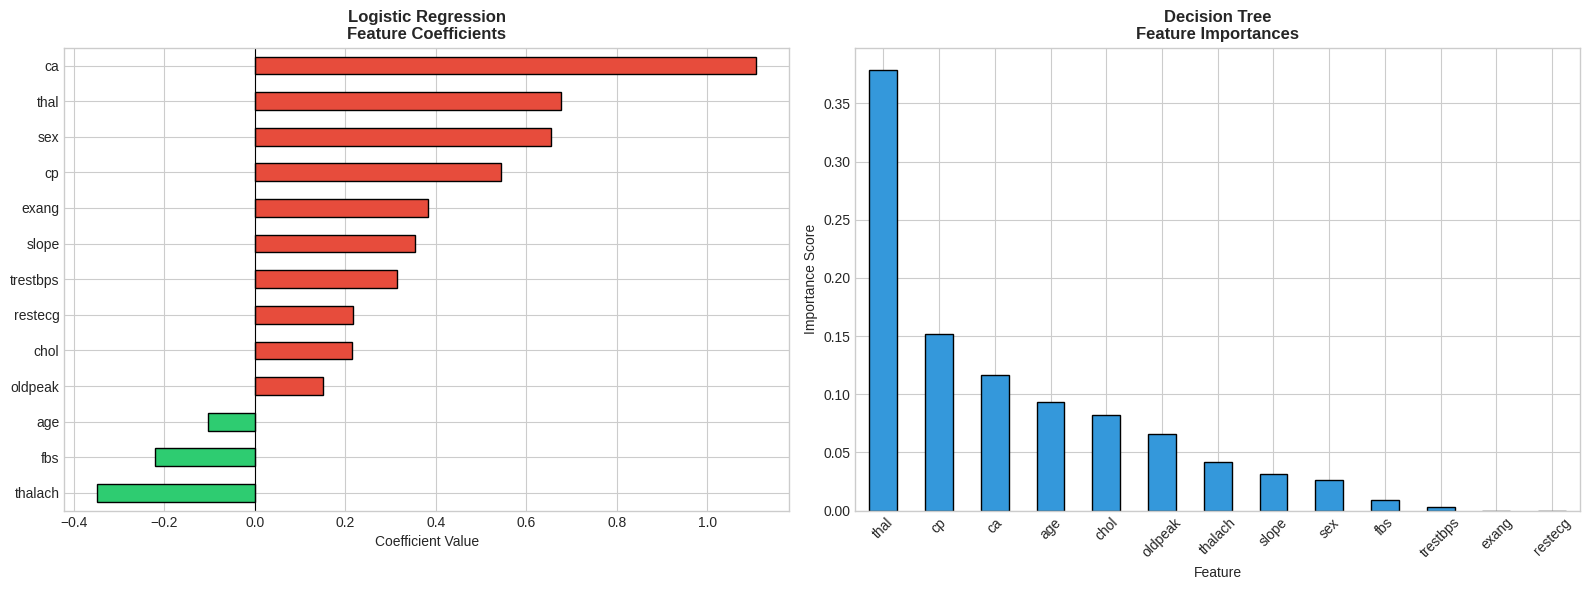


Top 5 Important Features (Decision Tree):
thal    0.378859
cp      0.151595
ca      0.116874
age     0.092980
chol    0.082157
dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression Coefficients
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values()
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression\nFeature Coefficients', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Decision Tree Feature Importances
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Decision Tree\nFeature Importances', fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Importance Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Important Features (Decision Tree):')
print(importances.head())

In [18]:
# Model Comparison Summary
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [round(acc_lr, 4), round(acc_dt, 4)],
    'ROC-AUC': [round(auc_lr, 4), round(auc_dt, 4)]
})
print('\n=== Model Comparison ===')
print(summary.to_string(index=False))


=== Model Comparison ===
              Model  Accuracy  ROC-AUC
Logistic Regression    0.8689   0.9513
      Decision Tree    0.7869   0.8047
